In [1]:
import tvm
import os
import json
import onnx
import onnxruntime as ort
import numpy as np
import urllib
from PIL import Image
import matplotlib.pyplot as plt
import pathlib
import platform

from MarvellMLTools.utils import tvm_mrvl_utils

In [2]:
model_url = "https://github.com/onnx/models/raw/refs/heads/main/validated/vision/classification/resnet/model/resnet50-v1-12.onnx"
local_model_path = "resnet50-v1-12.onnx"
local_optimized_model_path = "resnet50.onnx"
local_qdq_model_path = "resnet50_qdq.onnx"
urllib.request.urlretrieve(model_url, local_model_path)

!git clone https://github.com/EliSchwartz/imagenet-sample-images.git imagenet-dataset

Cloning into 'imagenet-dataset'...
remote: Enumerating objects: 1012, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 1012 (delta 3), reused 5 (delta 2), pack-reused 1002 (from 1)
Receiving objects: 100% (1012/1012), 103.84 MiB | 36.72 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [3]:
# Dynamic Batch Size to Fixed Batch Size 
tvm_mrvl_utils.set_fixed_batch_size(local_model_path, local_optimized_model_path, batch_size=1);

In [4]:
#Edit according to environment
INSTALL_PREFIX_HOST = "installx86"
TOOLCHAIN_DIR = "/opt/marvell-tools-12006.0"

In [5]:
cwd = pathlib.Path.cwd()

TARGET_TRIPLET = "aarch64-marvell-linux-gnu"
os.environ["TVM_CONFIGS_JSON_DIR"] = str(cwd / INSTALL_PREFIX_HOST / "share" / "tvm" / "configs")
os.environ["PATH"] += os.pathsep + str(cwd / INSTALL_PREFIX_HOST / "bin") + os.pathsep + str( pathlib.Path(TOOLCHAIN_DIR) / "bin")

MODEL_NAME = os.environ["MODEL_NAME"] = "resnet50"
MODEL_PATH = os.environ["MODEL_PATH"] = local_optimized_model_path

In [6]:
os.environ["MRVL_ENABLE_WB_PIN_OCM"] = str(1)
os.environ["MRVL_SAVE_MODEL_BIN"] = str(1)
os.environ["TVM_NUM_THREADS"] = str(1)

In [7]:
# Model compilation for cn10ka Simulator + LLVM x86_64 target, with fp16 quantization
quantize = "fp16"; run_mode = "sim"; arch = "cn10ka"

cmd = f"""
python3 -m tvm.driver.tvmc compile \
    --target='mrvl, llvm' \
    --target-mrvl-num_tiles 8 \
    --target-mrvl-mattr "{run_mode} -arch={arch} -quantize={quantize} -wb_pin_ocm=0" \
    --output "module_mrvl_{run_mode}_{quantize}.tar" \
    "{MODEL_PATH}"
"""

os.system(cmd)


===
= Welcome to Marvell ML Compiler - mrvl-tmlc (release SDK1x.25.08-986e)
                                 - MLLIB (release SDK1x.25.08-gfc81)
= Copyright (c) 2022 Marvell.
= All rights reserved.
===

Mrvl-Compiler-INFO::Quantization - Information
   => Convert to FP16 (given w: fp16, b: fp32, io: fp16)
*** IR1 graph generated (Time taken: 3277 milliseconds)
*** IR2 graph generated (Time taken: 875 milliseconds)
*** IR3 graph generated (Time taken: 41 milliseconds)
*** Debug: CS2 - CodegenSeqSort done (Time taken: 0 milliseconds)
******************************

*** Debug: CS3 - SetInpOutCstride done (Time taken: 0 milliseconds)
*** Debug: Sum(C2,C3) - CreateCodegenSequence() done (Time taken: 4 milliseconds)
*** codegen sequence generated (Sum(CS1,CS2,CS3): Time taken: 4 milliseconds)
*** Do MemDealloc Codgen Pass1 (Time taken: 46 milliseconds)
*** Real Codgen Pass2 (Time taken: 37 milliseconds)
Mrvl-Compiler-INFO::Converted Weights from HWC to CHW format (for mrvl-nn[0]).


Mrvl-Compiler-INFO::Generating bin file: ./bin_tvmgen_mrvl_main_0/tvmgen_mrvl_main_0.bin


*** model binary generated (Time taken: 4835 milliseconds)


0


=== Running inference for Image 1: n02236044_mantis.JPEG ===


2025-10-13 09:29:04.432 INFO load_module /tmp/tmp9kiu77t1/mod.so


===
= Welcome to Marvell SW Emulator - mlModel (SDK1x.25.09-g04543)
= Copyright (c) 2022 Marvell.
= All rights reserved.
===

cn10ka architecture mode using DDR memory

Running mlModel with following arguments:
 -> Model Binary file = /tmp/tvmgen_mrvl_main_0.bin
 -> Input Data file = /tmp/input.bin
 -> RunMode =  init+main+finish 


Initializing cn10ka
 -> Model Binary Metadata Version: 2.3.0.1
 -> Header Checksum (8c1b5751) verified.
 -> Payload Checksum (7b4aec45) verified.
 -> Weight and Bias data: Loaded 51116064 bytes to DRAM[0x0]
 -> Converted from FP32 to FP16
 -> Batch[0] - Input[0] data: Loaded 301056 bytes to DRAM[0x30bf880]
 -> Loading ISA.
 -> ISA: Loaded INIT section.
 -> ISA: Loaded MAIN section.
 -> ISA: Loaded FINISH section.
 -> Done.

SIM Running...
SIM Finished.

Global Stats:
    Model Name:                        tvmgen_mrvl_main_0
    Tiles active:                      8 (100.00%)
    Init cycles:                       70
    Main cycles:                       567

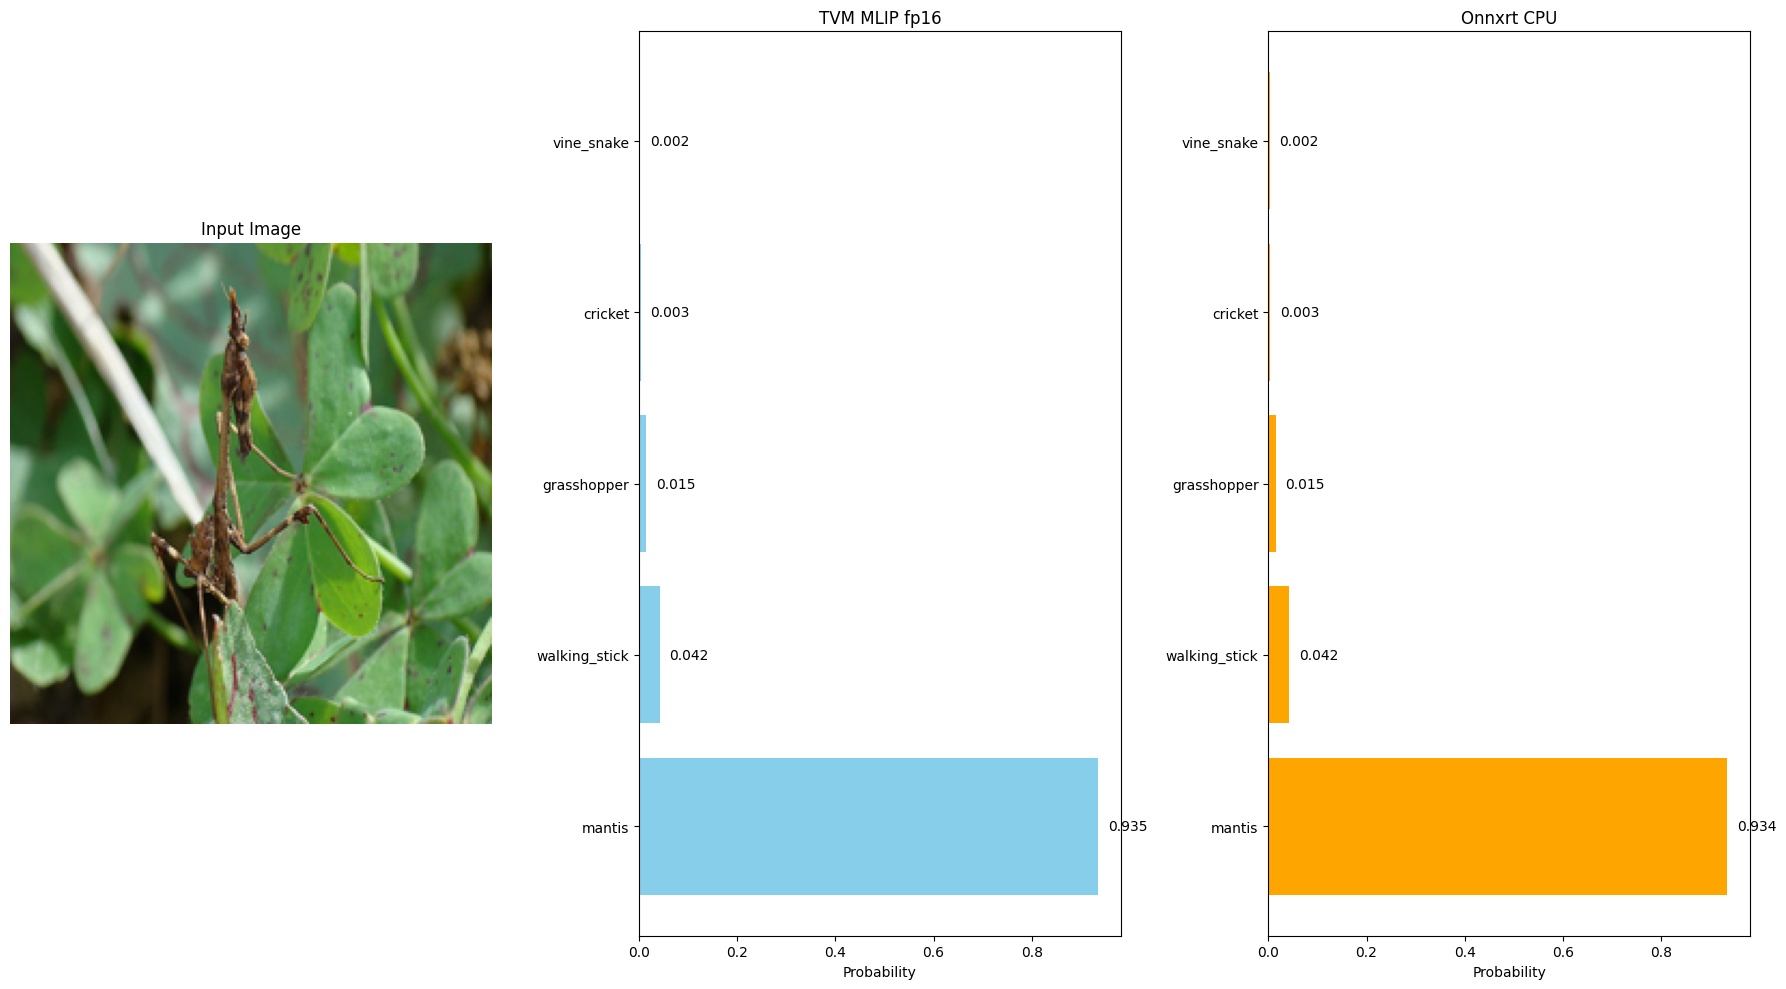


=== Running inference for Image 2: n02077923_sea_lion.JPEG ===


2025-10-13 09:50:54.254 INFO load_module /tmp/tmpbcb9vqcp/mod.so


===
= Welcome to Marvell SW Emulator - mlModel (SDK1x.25.09-g04543)
= Copyright (c) 2022 Marvell.
= All rights reserved.
===

cn10ka architecture mode using DDR memory

Running mlModel with following arguments:
 -> Model Binary file = /tmp/tvmgen_mrvl_main_0.bin
 -> Input Data file = /tmp/input.bin
 -> RunMode =  init+main+finish 


Initializing cn10ka
 -> Model Binary Metadata Version: 2.3.0.1
 -> Header Checksum (8c1b5751) verified.
 -> Payload Checksum (7b4aec45) verified.
 -> Weight and Bias data: Loaded 51116064 bytes to DRAM[0x0]
 -> Converted from FP32 to FP16
 -> Batch[0] - Input[0] data: Loaded 301056 bytes to DRAM[0x30bf880]
 -> Loading ISA.
 -> ISA: Loaded INIT section.
 -> ISA: Loaded MAIN section.
 -> ISA: Loaded FINISH section.
 -> Done.

SIM Running...
SIM Finished.

Global Stats:
    Model Name:                        tvmgen_mrvl_main_0
    Tiles active:                      8 (100.00%)
    Init cycles:                       70
    Main cycles:                       567

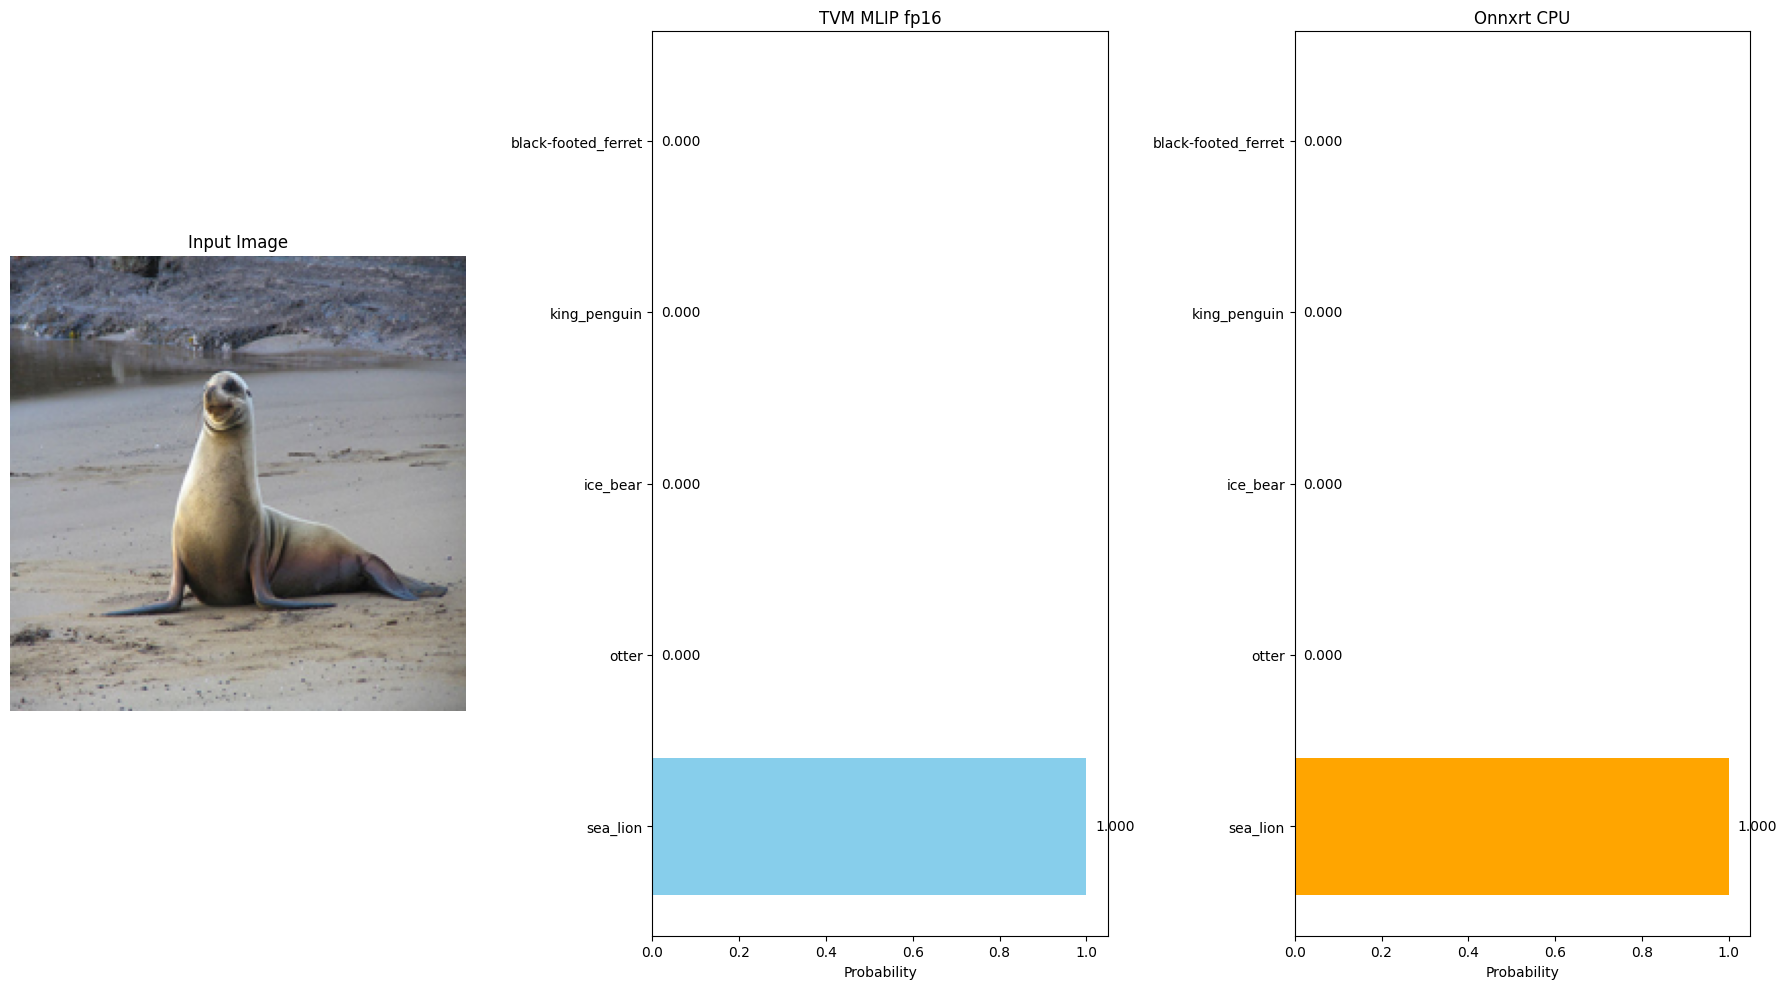


=== Running inference for Image 3: n03950228_pitcher.JPEG ===


2025-10-13 10:12:51.342 INFO load_module /tmp/tmp_0aq42xd/mod.so


===
= Welcome to Marvell SW Emulator - mlModel (SDK1x.25.09-g04543)
= Copyright (c) 2022 Marvell.
= All rights reserved.
===

cn10ka architecture mode using DDR memory

Running mlModel with following arguments:
 -> Model Binary file = /tmp/tvmgen_mrvl_main_0.bin
 -> Input Data file = /tmp/input.bin
 -> RunMode =  init+main+finish 


Initializing cn10ka
 -> Model Binary Metadata Version: 2.3.0.1
 -> Header Checksum (8c1b5751) verified.
 -> Payload Checksum (7b4aec45) verified.
 -> Weight and Bias data: Loaded 51116064 bytes to DRAM[0x0]
 -> Converted from FP32 to FP16
 -> Batch[0] - Input[0] data: Loaded 301056 bytes to DRAM[0x30bf880]
 -> Loading ISA.
 -> ISA: Loaded INIT section.
 -> ISA: Loaded MAIN section.
 -> ISA: Loaded FINISH section.
 -> Done.

SIM Running...
SIM Finished.

Global Stats:
    Model Name:                        tvmgen_mrvl_main_0
    Tiles active:                      8 (100.00%)
    Init cycles:                       70
    Main cycles:                       567

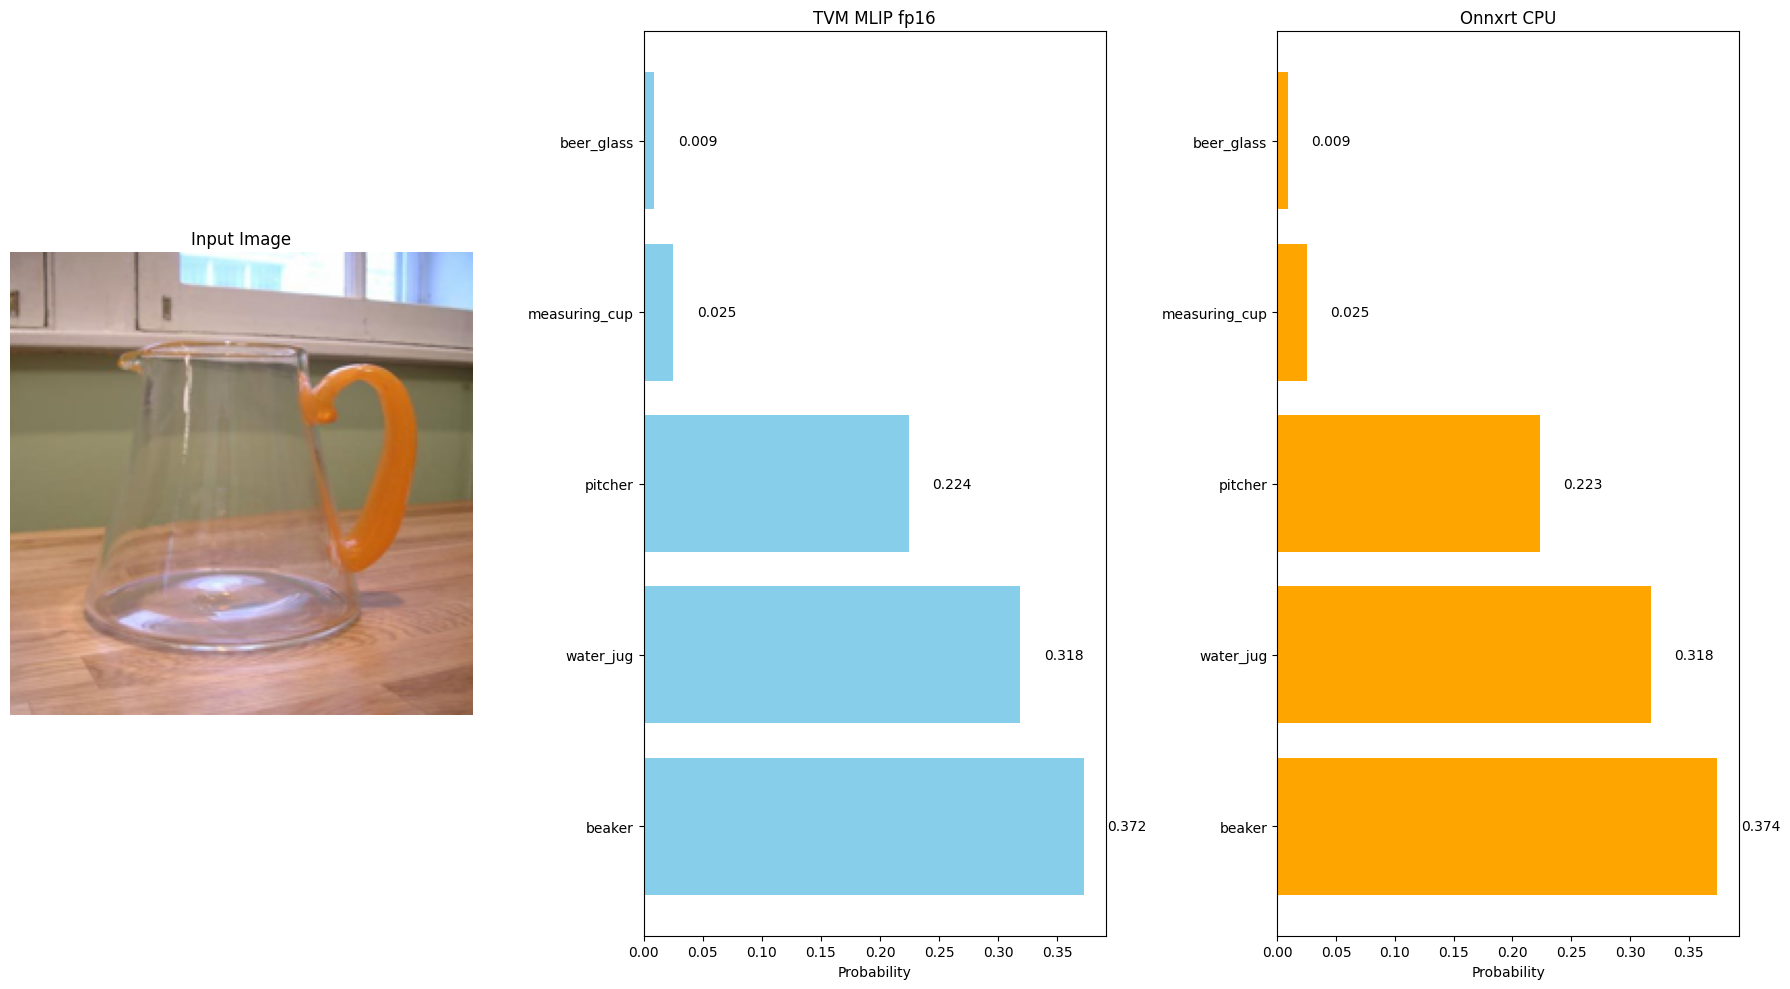

In [10]:
!rm -rf outputs/
!mkdir -p outputs

images_folder = os.path.join(os.getcwd(), "imagenet_dataset")
images_names = os.listdir(images_folder)

MAX_IMAGES = 3
for idx, img_path in enumerate(images_names[:MAX_IMAGES], 1):
    print(f"\n=== Running inference for Image {idx}: {img_path} ===")

    # Prepare input .npz file
    input_npz_path = os.path.join("outputs", f"input_{idx}.npz")
    img = tvm_mrvl_utils.get_resnet50_sample_image(image_path=os.path.join(images_folder, img_path), input_npz_path=input_npz_path)
    
    # Run TVM Mrvl Inference (SIM)
    out_mrvl_sim_fp16_npz_path = os.path.join("outputs", f"mrvl_sim_fp16_{idx}.npz")
    os.environ["MRVL_ML_ARCH"] = "cn10ka"
    cmd = f"python3 -m tvm.driver.tvmc run \
        --inputs {input_npz_path} \
        --outputs {out_mrvl_sim_fp16_npz_path} \
        --number=1 \
        module_mrvl_sim_fp16.tar"
    os.system(cmd)

    # Run ONNX Runtime inference
    out_onnxrt_npz_path = os.path.join("outputs", f"onnxrt_{idx}.npz")
    tvm_mrvl_utils.run_onnxrt_inference(local_optimized_model_path, input_npz_path, out_onnxrt_npz_path)

    # Display results
    fig, axs = plt.subplots(1, 3, figsize=(18, 10))
    fig.subplots_adjust(wspace=0.5, hspace=0.4)
    axs[0].imshow(img)
    axs[0].axis('off')
    axs[0].set_title("Input Image")
    tvm_mrvl_utils.predict(out_mrvl_sim_fp16_npz_path, axs[1], 'skyblue', "TVM MLIP fp16")
    tvm_mrvl_utils.predict(out_onnxrt_npz_path, axs[2], 'orange', "Onnxrt CPU")

    plt.tight_layout()
    plt.show()